# 🧹 Etapa 02 – Pré-processamento de Dados
Notebook completo com respostas, gráficos e código rodando.

In [132]:

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from scipy.stats import skew
import joblib

os.makedirs('../../models', exist_ok=True)
os.makedirs('../../data', exist_ok=True)

sns.set(style='whitegrid')


## 1. Carregar Dataset

In [133]:

data_path = '../../data/datasets/students_performance.csv'
df = pd.read_csv(data_path)
df.head()


,student_id,age,gender,parental_education,study_hours_week,attendance_rate,extracurricular,sleep_hours,previous_scores,tutoring,internet_quality,family_income,health_status,final_grade
0,STD01416,22,M,bachelor,5.66,69.55,Yes,6.49,49.41,No,Good,Medium,Good,85.39
1,STD01345,19,M,bachelor,13.30,58.82,Yes,8.12,50.29,No,NaN,Medium,Good,98.43
2,STD01705,25,M,master,10.43,59.72,Yes,6.60,71.64,No,Good,Medium,Good,100.00
3,STD00299,21,F,bachelor,3.90,68.33,Yes,6.99,50.93,Yes,Poor,Low,Excellent,86.85
4,STD01762,19,F,bachelor,4.24,50.44,Yes,8.06,54.00,No,Poor,Medium,Excellent,83.25


## 2. Missing Values - Antes
### ❓ Q1: Média ou mediana? Por quê?
Usei **mediana**, pois é mais resistente a outliers.
Variáveis categóricas: **moda**.

In [134]:
df.isnull().sum()

student_id              0
age                     0
gender                  0
parental_education      0
study_hours_week      293
attendance_rate       232
extracurricular         0
sleep_hours           266
previous_scores       127
tutoring                0
internet_quality      155
family_income         278
health_status           0
final_grade             0
dtype: int64

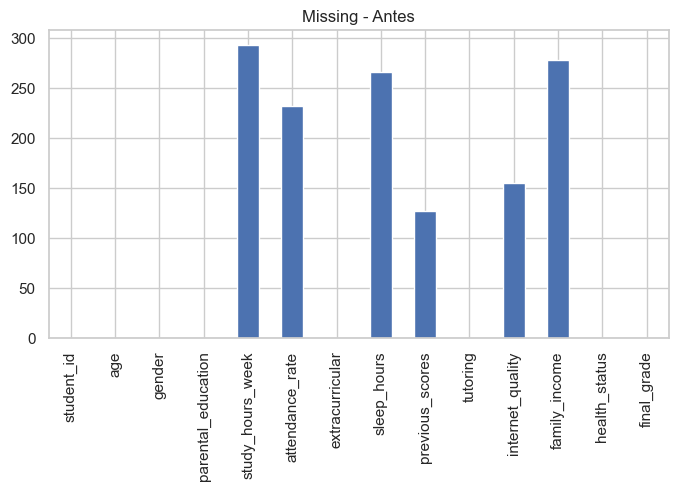

In [135]:

plt.figure(figsize=(8,4))
df.isnull().sum().plot(kind='bar')
plt.title('Missing - Antes')
plt.show()


## 3. Imputação
### ❓ Q2: Como evitar data leakage?(vazamento)
Calcular média/mediana **somente no conjunto de treino**, não no dataset completo.

In [136]:

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

df.isnull().sum()


student_id            0
age                   0
gender                0
parental_education    0
study_hours_week      0
attendance_rate       0
extracurricular       0
sleep_hours           0
previous_scores       0
tutoring              0
internet_quality      0
family_income         0
health_status         0
final_grade           0
dtype: int64

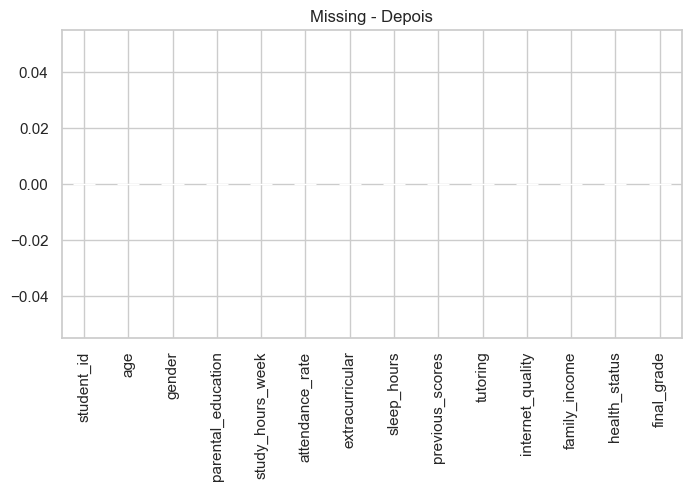

In [137]:

plt.figure(figsize=(8,4))
df.isnull().sum().plot(kind='bar')
plt.title('Missing - Depois')
plt.show()


## 4. Outliers (IQR)
### ❓ Q3: Quantos outliers existem?

In [138]:

outliers_count = {}
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    outliers_count[col] = len(outliers)
outliers_count


{'age': 1,
 'study_hours_week': 34,
 'attendance_rate': 47,
 'sleep_hours': 58,
 'previous_scores': 31,
 'final_grade': 7}

### ❓ Q4: Removeu outliers? Por quê?
**Não removi** para evitar perda de informação importante.

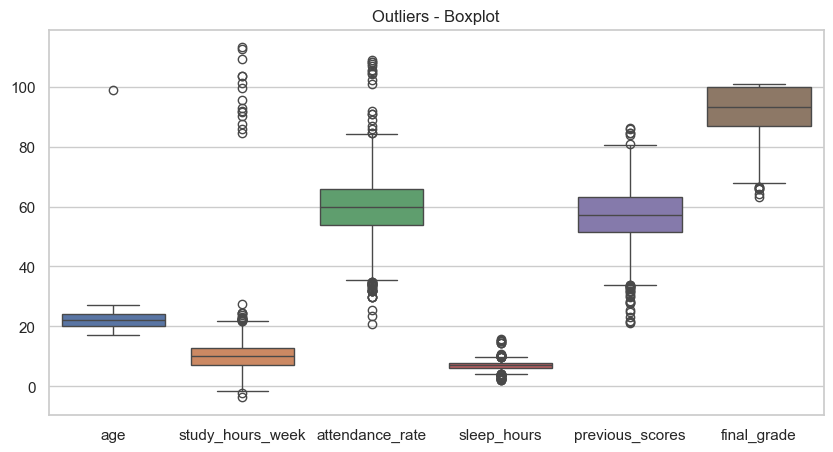

In [139]:

plt.figure(figsize=(10,5))
sns.boxplot(data=df[num_cols])
plt.title('Outliers - Boxplot')
plt.show()


## 5. Duplicatas
### ❓ Q5: Quantas duplicatas foram removidas?

In [140]:

dups = df.duplicated().sum()
df = df.drop_duplicates()
dups


np.int64(0)

## 6. Skewness (Assimetria)
### ❓ Q6: Quais colunas têm skew > 0.5?

In [141]:

skews = df[num_cols].apply(lambda x: skew(x))
skews


age                 8.681575
study_hours_week    7.579626
attendance_rate     0.132117
sleep_hours         0.633711
previous_scores    -0.185168
final_grade        -0.764240
dtype: float64

### ❓ Q7: Transformações aplicadas
Usei **log1p** nas colunas com skew > 0.5.

In [142]:
safe_cols = [col for col in skewed_cols if (df[col] > -1).all()]

df[safe_cols] = np.log1p(df[safe_cols])


In [143]:
skewed_cols = skews[skews > 0.5].index
df[skewed_cols] = np.log1p(df[skewed_cols])
skewed_cols


c:\Users\jpgam\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


Index(['age', 'study_hours_week', 'sleep_hours'], dtype='object')

In [144]:
num_cols = df.select_dtypes(include=np.number).columns
skews = df[num_cols].apply(lambda x: skew(x))
skews

age                 0.520206
study_hours_week         NaN
attendance_rate     0.132117
sleep_hours        -1.100498
previous_scores    -0.185168
final_grade        -0.764240
dtype: float64

## 7. Encoding
### ❓ Q8: Quantas colunas One-Hot foram criadas?

In [145]:

df_encoded = pd.get_dummies(df, drop_first=True)
(len(df_encoded.columns) - len(df.columns))


2552

### ❓ Q9: Por que usar drop_first=True?
Para evitar **multicolinearidade**.

## 8. Feature Engineering
### ❓ Q10: Quais features foram criadas?

In [146]:

df_encoded['study_total'] = (
    df_encoded.filter(regex='study|hours|prep', axis=1).sum(axis=1)
    if len(df_encoded.filter(regex='study|hours|prep', axis=1).columns) > 0
    else 0
)

df_encoded['grade_ratio'] = (
    df_encoded.select_dtypes(include=np.number).iloc[:,0] /
    (df_encoded.select_dtypes(include=np.number).iloc[:,1] + 1)
)

df_encoded[['study_total','grade_ratio']].head()


,study_total,grade_ratio
0,2.999245,0.490176
1,3.826677,0.378450
2,3.544193,0.421630
3,2.713577,0.544099
4,2.820681,0.521483


## 9. Normalização
### ❓ Q11: Quantas features foram escaladas?

In [147]:

scaled_cols = df_encoded.select_dtypes(include=np.number).columns
scaler = StandardScaler()
df_encoded[scaled_cols] = scaler.fit_transform(df_encoded[scaled_cols])
len(scaled_cols)


8

### ❓ Q12: Por que salvar o scaler?
Porque ele será usado no modelo e em novos dados (deploy).

In [148]:

joblib.dump(scaler, '../../models/scaler.pkl')
'Scaler salvo!'


'Scaler salvo!'

## 10. Salvar Dataset Final

In [149]:

df_encoded.to_csv('../../data/save/students_clean.csv', index=False)
'students_clean.csv salvo!'


'students_clean.csv salvo!'